In [106]:
import os
import glob
import itertools
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import chirp, find_peaks, peak_widths

functions

In [107]:
# 定义函数


def separate_session(df, threshold=3):
    df = pd.read_csv(df, index_col=0)
    df['index_col'] = pd.to_numeric(df.index, errors='coerce')
    check_points = [0]  # 初始化第一个分割点为0（DataFrame的起始位置）
    frame_list = df['index_col'].values.tolist()
    

    # 判断两行之间的时间差，大于threshold则视为新的session
    for i in range(len(frame_list) - 1):
        if (frame_list[i+1] - frame_list[i]) > threshold:
            check_points.append(frame_list[i+1])
    
    check_points.append(frame_list[-1] + 1)  # 添加最后一个分割点

    session_dfs = []
    for i in range(len(check_points) - 1):
        session_df = df[(df['index_col'] >= check_points[i]) & (df['index_col'] < check_points[i+1])]
        session_df.drop(columns='index_col', inplace=True)
        session_dfs.append(session_df)

    return session_dfs
   
 

# 处理分离后的session文件，使每个session的开始时间为0
def process_frame(df):
    # 获取DataFrame的index并转换为float类型的list
    index_list = [float(index) for index in df.index]

    # 判断第一个index的值是否为0，并进行相应处理
    if index_list[0] != 0:
        # 如果第一个index的值不为0，将所有index值减去第一个index值，以实现“相对于第一个index的增量”效果
        index_list = [index - index_list[0] for index in index_list]

    return index_list

  
def process_event_interval(df):
    # 从DataFrame中提取'From Second'和'To Second'列，并转换为二维列表
    event_list = df[['From Second', 'To Second']].values.tolist()

    # 返回处理后的新事件列表
    return event_list



# 获得事件标记
def get_event_label(event_df):
    
    '''
    Aim:
        for OFT
        translate 'event' in eventFile to integer label
        each row (corresponding to each time interval) of event is assigned a label
        called in function `add_event_label()`
    '''
    
    # get event status list
    Event_status = event_df['Event'].values.tolist()
    # compact event label list for three sessions
    event_label = []
    for i in Event_status:   
        if i.strip() == 'sniff':
            event_label.append(11)
        elif i.strip() == 'sniffed' :
            event_label.append(12)
        elif i.strip() == 'freezing':
            event_label.append(21)
        elif i.strip() == 'cs':
            event_label.append(22)
        elif i.strip() == 'In_all':
            event_label.append(23)
        else:
            event_label.append(24)

    return(event_label)


# 添加事件标签
def add_event_label(trace_df, event_path):

    '''
    Aim:
        add event_label to each frame
        one frame can have several label (since mouse can in a location and do something)
    
    Retrun:
        trace dataframe with one label column
    '''
    
    frame_list = process_frame(trace_df)
    #get event dataframe/eventIntervals/eventLabel
#     event_df = pd.read_csv(event_path)
    event_df = pd.read_excel(event_path)
    interval_list = process_event_interval(event_df)
    event_label = get_event_label(event_df)

    
    # add label to each frame
    frame_label_list = []
    for frame in frame_list:
        frame_label = str()
        
        for i in range(len(interval_list)): # one frame can be in several interval
            if min(interval_list[i])  <= frame <= max(interval_list[i]) :
                frame_label = frame_label+ str(event_label[i])

        # convert str to int
        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        # append frame label to list
        frame_label_list.append(frame_label)
    
    
    # add label list to trace df 
    new_df = trace_df.copy()
    new_df['Frame_Label']  =  frame_label_list
    new_df = new_df.dropna()
    

    return(new_df)


In [115]:
# 检查特定状态下的帧间隔，并返回满足条件的数据子集
def check_frame_interval(df, which_status_to_check_frame):
    
    # set up which_status_to_check_frame
    
    if which_status_to_check_frame == 'sniff':
        which_status_to_check_frame = str(11)
    elif which_status_to_check_frame == 'sniffed':
        which_status_to_check_frame = str(12)
    elif which_status_to_check_frame == 'freezing':
        which_status_to_check_frame = str(21)
    elif which_status_to_check_frame == 'cs':
        which_status_to_check_frame = str(22)
    elif which_status_to_check_frame == 'In_all':
        which_status_to_check_frame = str(23)
    else:
        raise ValueError('Not approved status. choose from: Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_all, In_left')

    #df = add_event_label(df, event_1_path, event_2_path, event_3_path, mice_path)[which_session]
    frame_label_list = df['Frame_Label'].values.tolist()
    
    # to separate status label, eg:20214111
    n = 2
    
    check_frame_label_list = []
    for line in frame_label_list:
        line = str(line)
        line_list= [line[i:i+n] for i in range(0, len(line), n)]
        if which_status_to_check_frame in line_list:
            check_frame_label_list.append(1)
        else:
            check_frame_label_list.append(0)       
            
    
            
    df['status'] = check_frame_label_list
    df_keep = df[ (df['status'] == 1)]
    df_keep = df_keep.drop('status', axis = 1)
    df_keep = df_keep.drop('Frame_Label', axis = 1)
    
    #print('the shape of the dataframe in the status is:', df_keep.shape)
    return(df_keep)




def event_rate(df, fps):
    # 将非数值值转换为NaN
    df = df.apply(pd.to_numeric, errors='coerce')
    
    # 获取数据框的行数和列数
    Frames, n_neuron = df.shape
    # 将数据框转换为NumPy数组
    df_array = df.to_numpy()

    peak_sum = 0
    amplitude_mean_list = []          # 用于存储每个神经元的峰值均值
    amplitude_mean_list_wit_zero = []  # 用于存储每个神经元的峰值均值（包括没有峰值的情况）
    peak_info_list = []                # 用于存储每个神经元的峰值信息

    # 遍历每个神经元
    for i in range(n_neuron):
        # 使用find_peaks函数查找峰值
        peaks, _ = find_peaks(df_array[:, i], prominence=5.5, width=2)   ############## find peaks ##########################################################
        peak_sum += len(peaks)  # 累计所有神经元的峰值数量
        
        # 处理有峰值的情况
        if len(peaks) != 0:
            amplitude_mean = np.mean(df_array[:, i][peaks])  # 计算有峰值神经元的峰值均值
            amplitude_mean_list.append(amplitude_mean)
            amplitude_mean_list_wit_zero.append(amplitude_mean)
        else:
            amplitude_mean_list_wit_zero.append(0)  # 没有峰值的神经元，均值为0

        # 将峰值信息添加到列表中
        peak_info_list.append({'neuron_index': i, 'peaks': peaks})

    # 计算事件率
    if Frames != 0 and n_neuron != 0:
        event_rate = peak_sum / (Frames / fps) / n_neuron
    else:
        event_rate = np.nan  # 若数据为空，事件率为NaN

    # 计算所有神经元的峰值均值
    amplitude = np.mean(amplitude_mean_list)
    # 计算所有神经元的峰值均值（包括没有峰值的情况）
    amplitude_00 = np.mean(amplitude_mean_list_wit_zero)

    # 返回计算结果
    return event_rate, amplitude, amplitude_00, df_array, peak_info_list

# 先独立运行完seperate session,再进行后面的Transient rate的分析
只需要参考一只小鼠的处理流程。不同小鼠除了文件保存路径不同外其他代码相同。

# Separate sessions & Save for later use

In [103]:
root_path = 'F:/AAA-RXC'
data_path = os.path.join(root_path)
# F:/AAA-Social analysis/Data-Neuron Social/AAA-PL/1-PL04-SOCIAL

IL1_list = ['PL1-4sessions', 'PL2-4sessions', 'PL4-4sessions', 'PL5-4sessions', 'PL6-4sessions', 'PL7-4sessions', 'PL8-4sessions',]
WT_mouse = ['WT']*len(IL1_list)

session_ids = [1,2,3,4]

In [104]:
#分离不同的session。根据TRACE文件中的'time'列中的值，将不同的session区分开。
def separate_session(df, threshold=3):
    df = pd.read_csv(df, index_col=0)
    
    df.columns = [c.strip() for c in df.columns]  #去除TRACE文件标题列的空格

    df['index_col'] = pd.to_numeric(df.index, errors='coerce')
    check_points = [0]  # 初始化第一个分割点为0（DataFrame的起始位置）
    frame_list = df['index_col'].values.tolist()

    # 判断两行之间的时间差，大于threshold则视为新的session
    for i in range(len(frame_list) - 1):
        if (frame_list[i+1] - frame_list[i]) > threshold:
            check_points.append(frame_list[i+1])
    
    check_points.append(frame_list[-1] + 1)  # 添加最后一个分割点

    session_dfs = []
    for i in range(len(check_points) - 1):
        session_df = df[(df['index_col'] >= check_points[i]) & (df['index_col'] < check_points[i+1])]
        session_df.drop(columns='index_col', inplace=True)
        session_dfs.append(session_df)

    return session_dfs

In [105]:
for i in range(len(IL1_list)):
    
    mouseSummary = IL1_list[i]
    mouseName = mouseSummary[-11:-7]   ### mouse name selected from file name
    mouseType = WT_mouse[i]
    print("Processing ", mouseName+'-'+mouseType)
    
    trace = os.path.join(data_path, mouseSummary, "TRACE_Con.csv")
    df_traces = separate_session(trace)

    for session_id in session_ids:
        event = os.path.join(data_path, mouseSummary, f"event{session_id}.xlsx")
        #event = os.path.join(data_path, mouseSummary, f"event.xlsx")
        #onoff = os.path.join(data_path, mouseSummary, project+'ONOFF.csv')
    
        session = df_traces[session_id-1]
        session.index.name="Frame"
        session.index = pd.to_numeric(session.index)
        session_frame_label = add_event_label(session, event)

        session_frame_label.to_csv(os.path.join(data_path, mouseSummary, f"session_{session_id}_trace.csv"))

        print(mouseName, f"session_{session_id}_trace has shape:", session_frame_label.shape)

    print('Done')
    session_frame_label.head(2)   
    

Processing  1-4s-WT


C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_df.drop(columns='index_col', inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#

1-4s session_1_trace has shape: (9004, 64)
1-4s session_2_trace has shape: (6303, 64)
1-4s session_3_trace has shape: (6303, 64)
1-4s session_4_trace has shape: (6302, 64)
Done
Processing  2-4s-WT


C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_df.drop(columns='index_col', inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

2-4s session_1_trace has shape: (9005, 68)
2-4s session_2_trace has shape: (6302, 68)
2-4s session_3_trace has shape: (6303, 68)
2-4s session_4_trace has shape: (6302, 68)
Done
Processing  4-4s-WT


...

6-4s session_1_trace has shape: (9005, 57)
6-4s session_2_trace has shape: (6303, 57)
6-4s session_3_trace has shape: (6303, 57)
6-4s session_4_trace has shape: (6302, 57)
Done
Processing  7-4s-WT


C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_df.drop(columns='index_col', inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

7-4s session_1_trace has shape: (9004, 103)
7-4s session_2_trace has shape: (6303, 103)
7-4s session_3_trace has shape: (6303, 103)
7-4s session_4_trace has shape: (6303, 103)
Done
Processing  8-4s-WT


C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  session_df.drop(columns='index_col', inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10260\2922488257.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentat

8-4s session_1_trace has shape: (9004, 89)
8-4s session_2_trace has shape: (6303, 89)
8-4s session_3_trace has shape: (6302, 89)
8-4s session_4_trace has shape: (6302, 89)
Done


# 绘图
利用这段代码绘制图像，调整event_rate函数中find_peaks的具体参数

In [92]:
def plot_peak_info(df_array, peak_info_list):
    for peak_info in peak_info_list:
        neuron_index = peak_info['neuron_index']
        peaks = peak_info['peaks']

        plt.figure()
        plt.plot(df_array[:, neuron_index])
        plt.plot(peaks, df_array[peaks, neuron_index], "x", label="peaks")
        plt.title(f'Neuron {neuron_index} Peaks')
        plt.legend()
        plt.show()

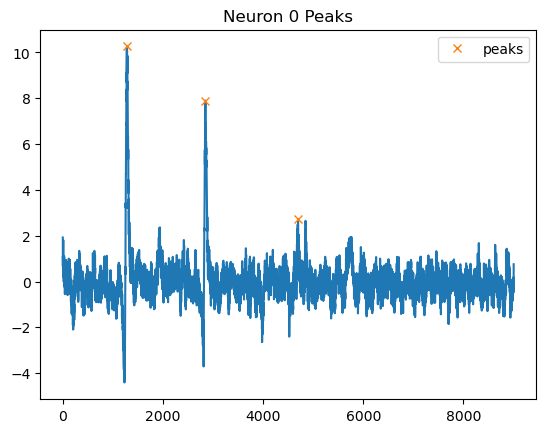

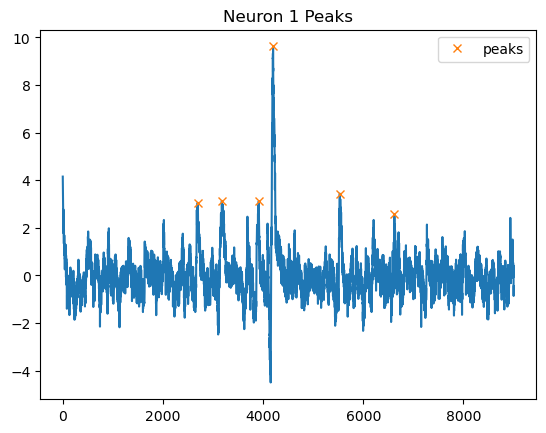

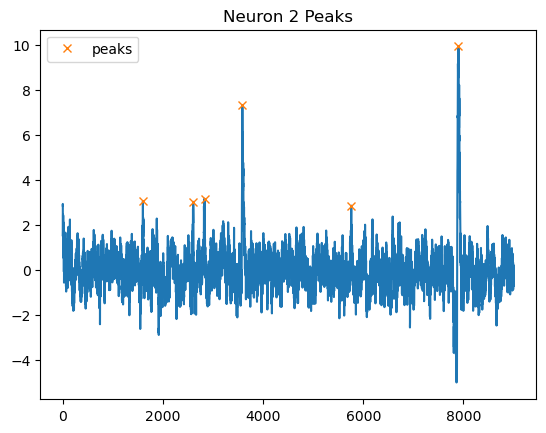

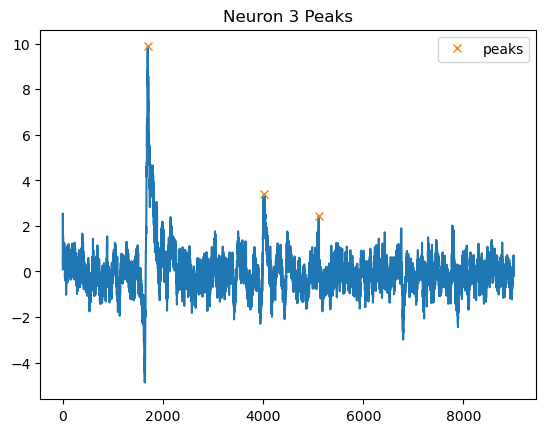

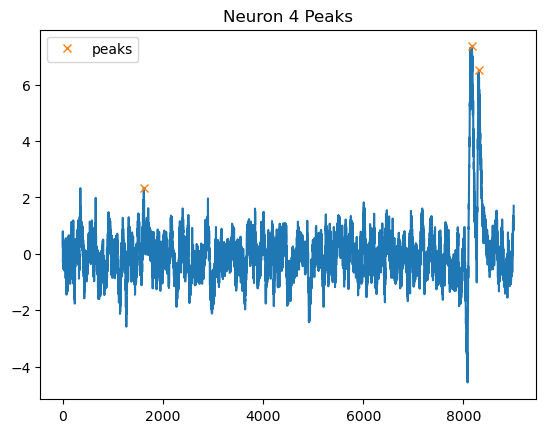

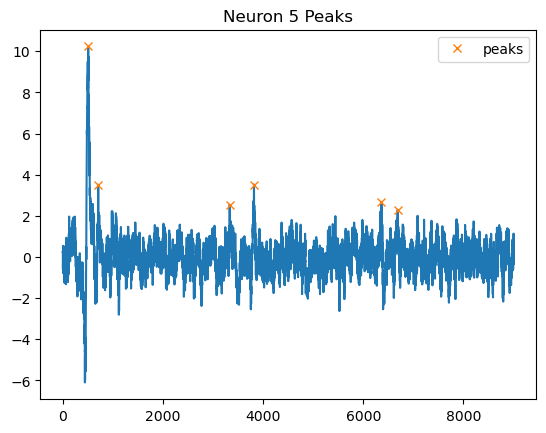

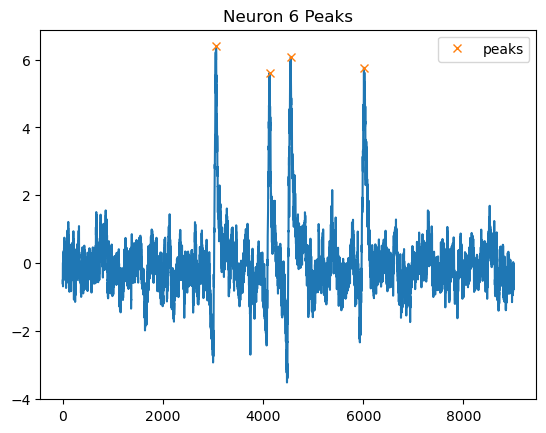

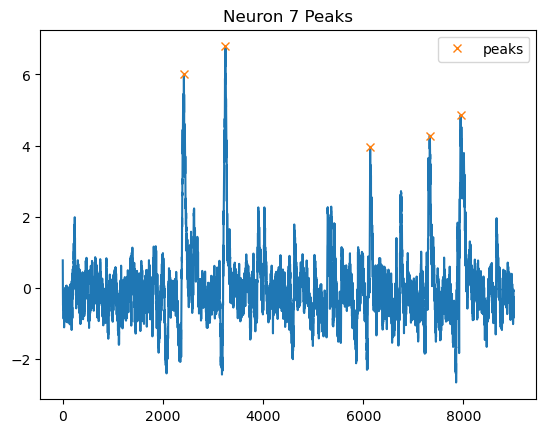

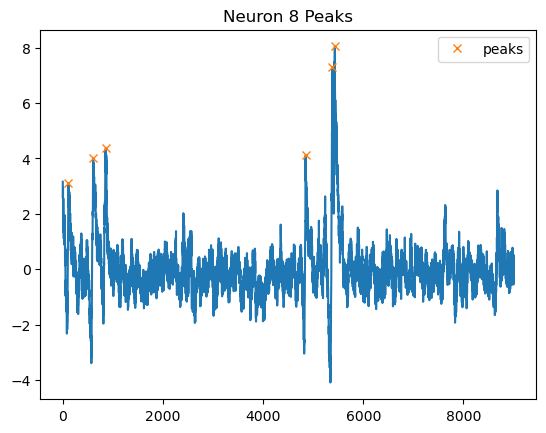

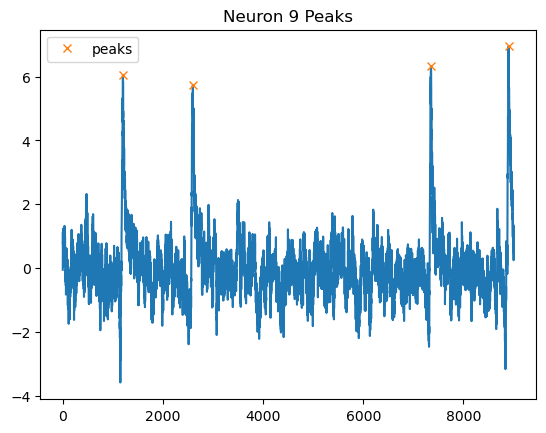

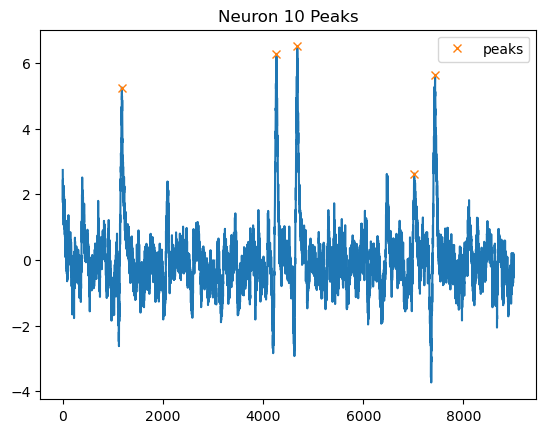

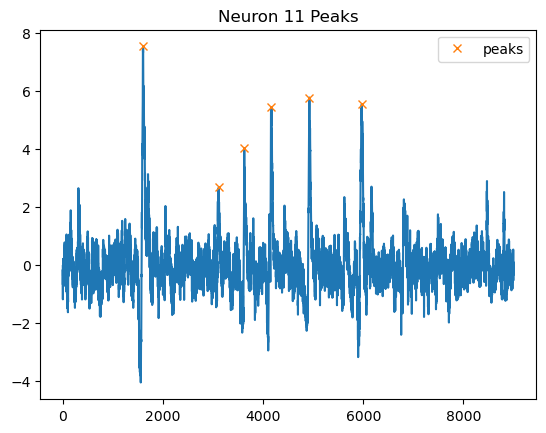

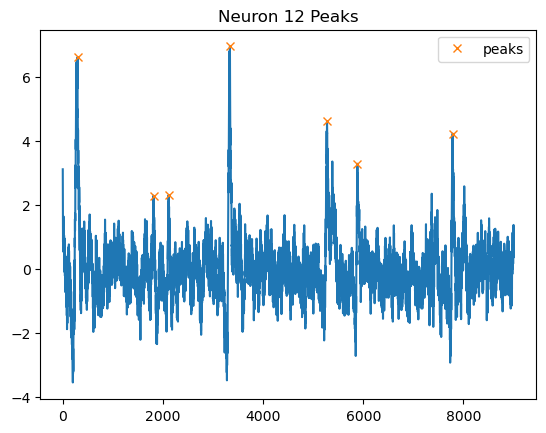

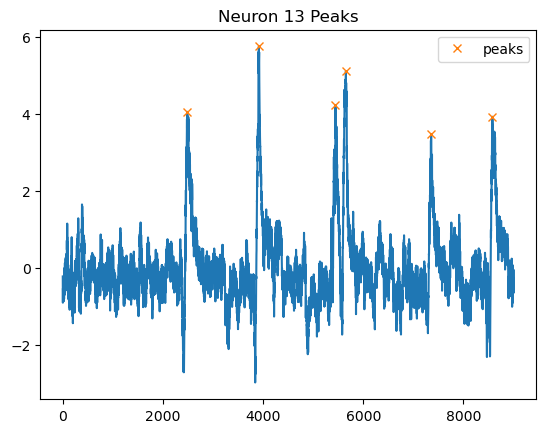

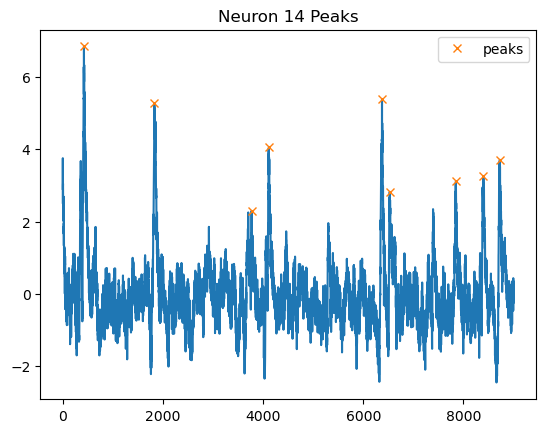

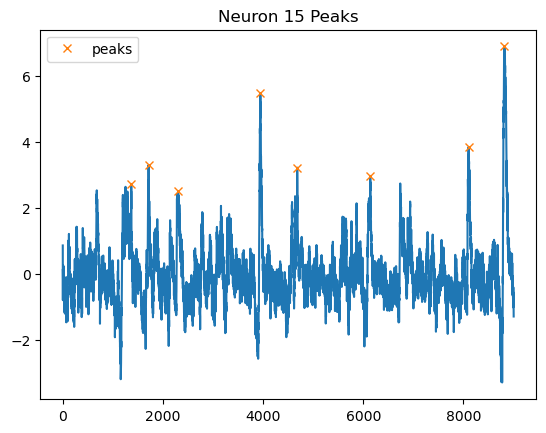

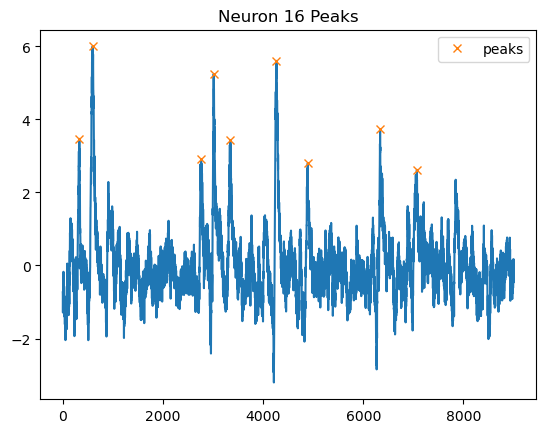

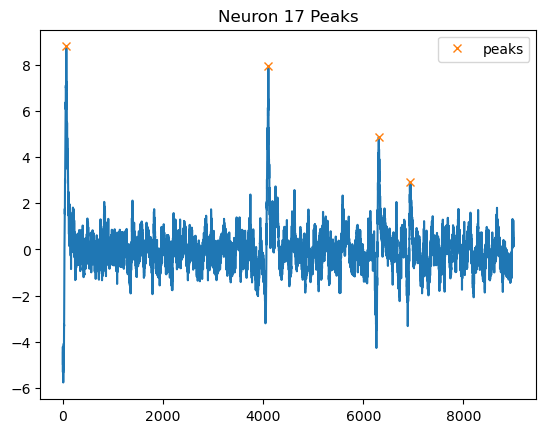

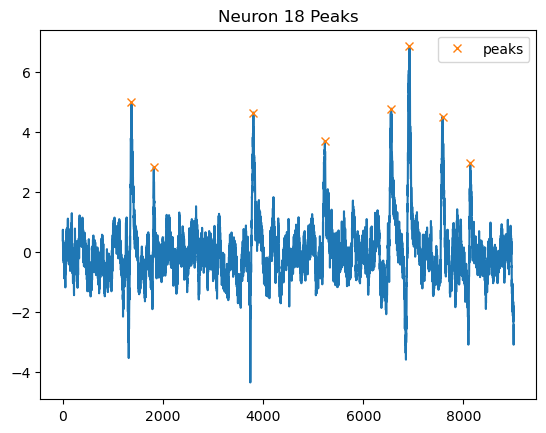

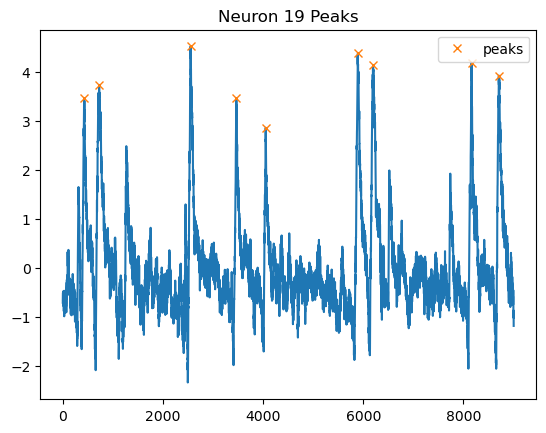

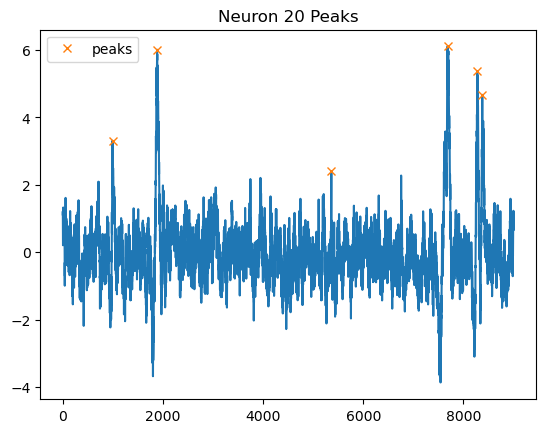

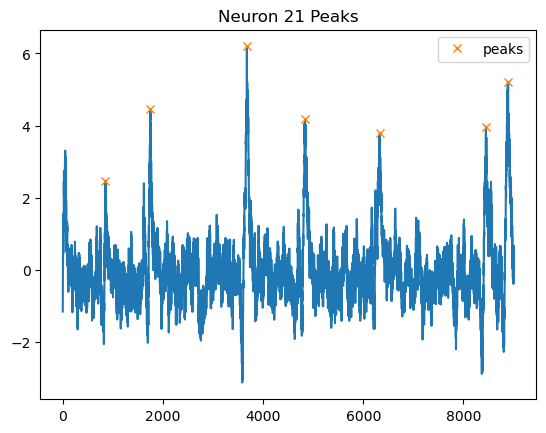

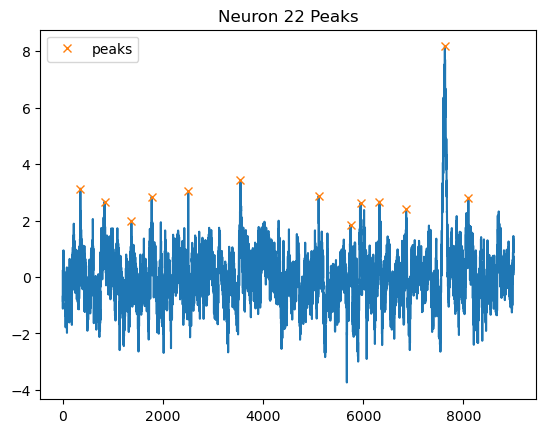

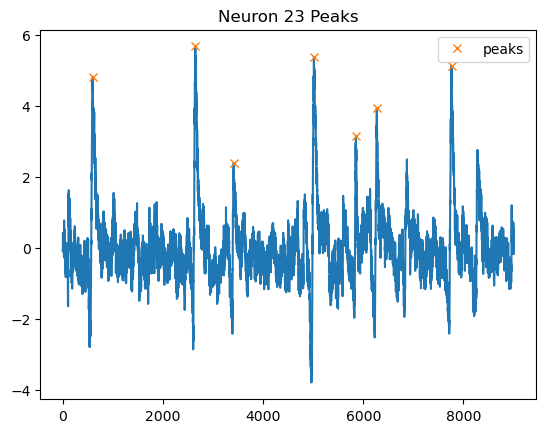

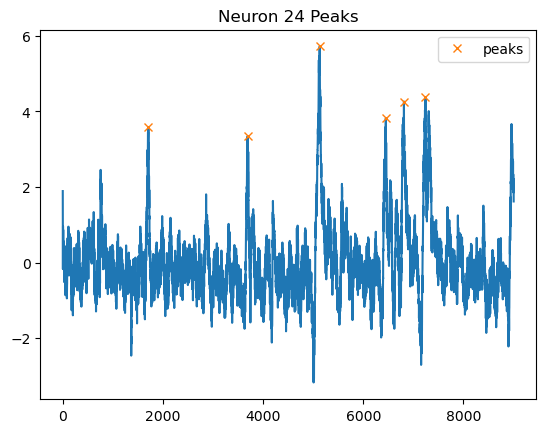

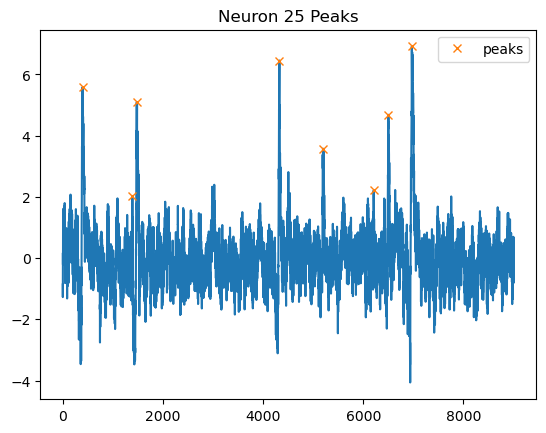

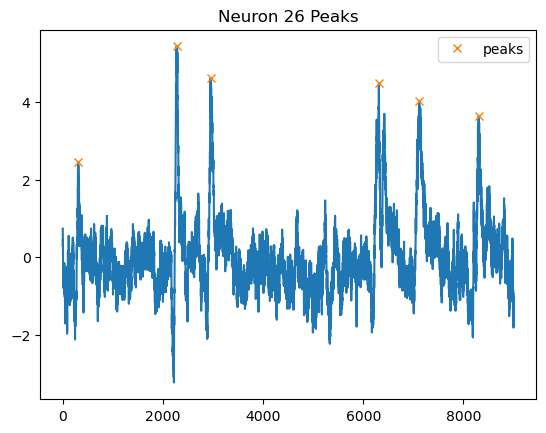

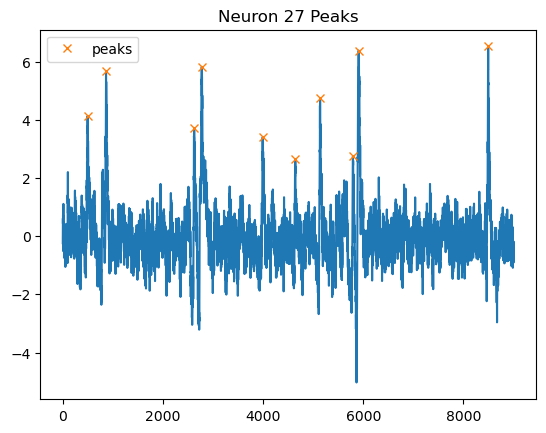

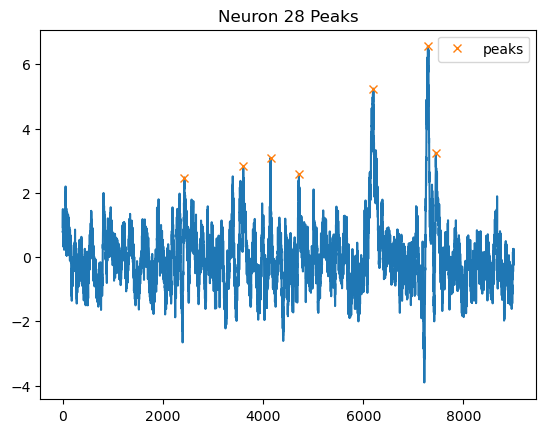

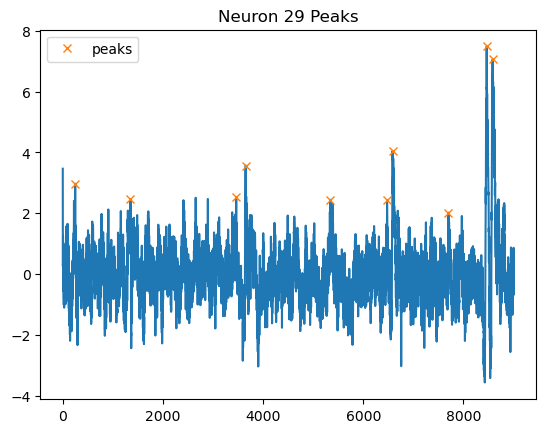

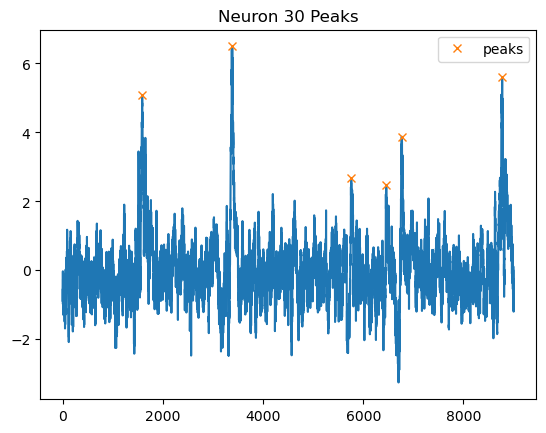

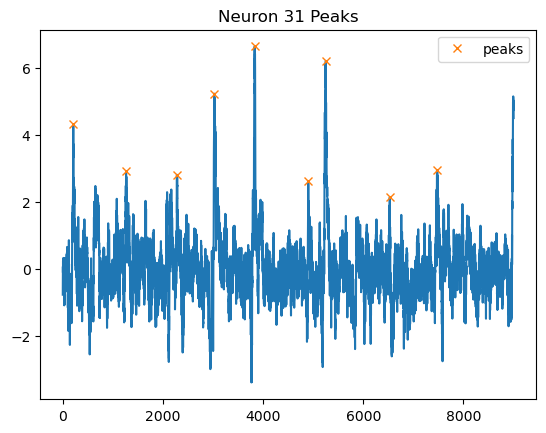

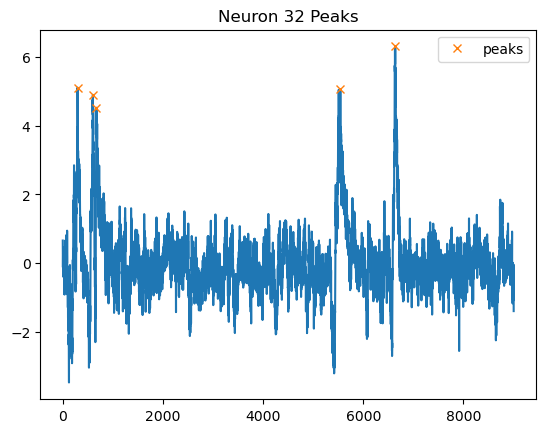

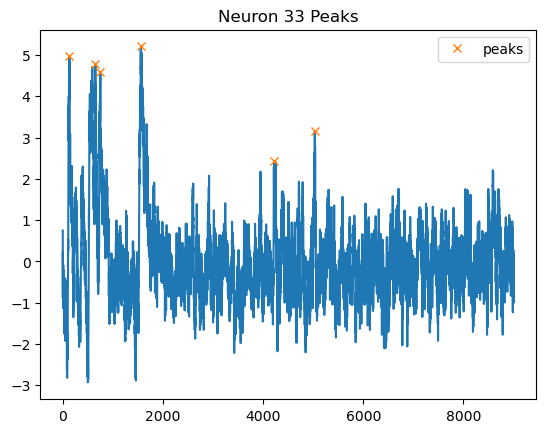

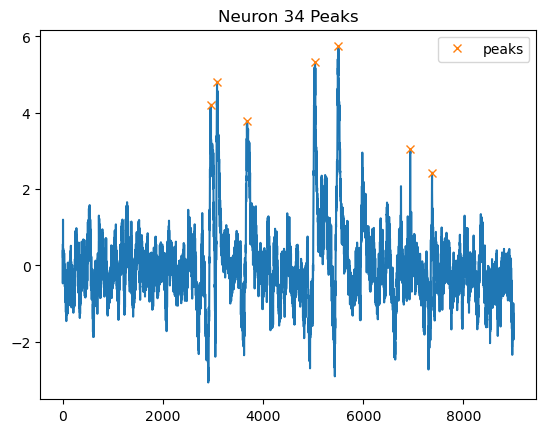

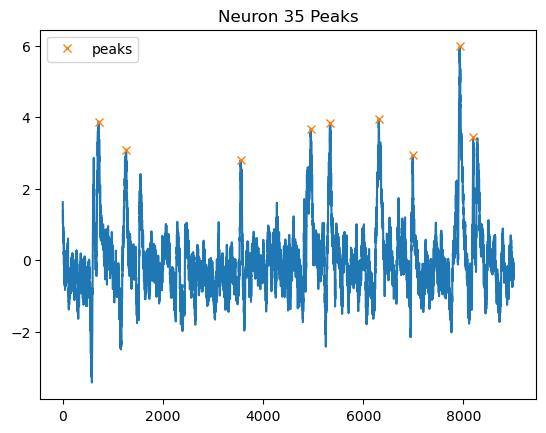

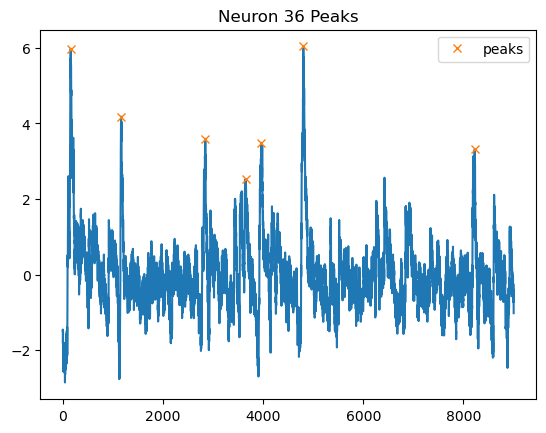

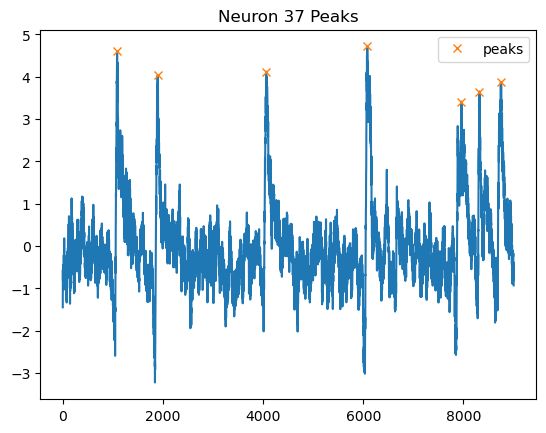

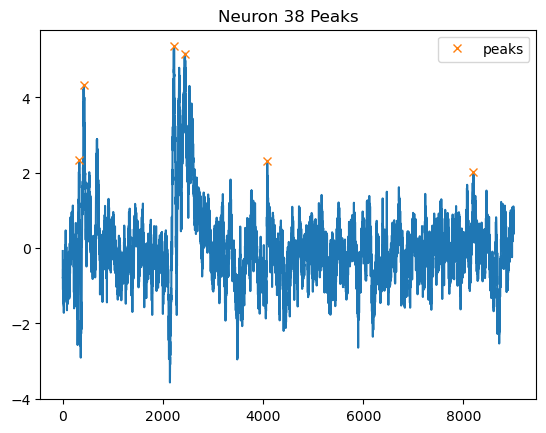

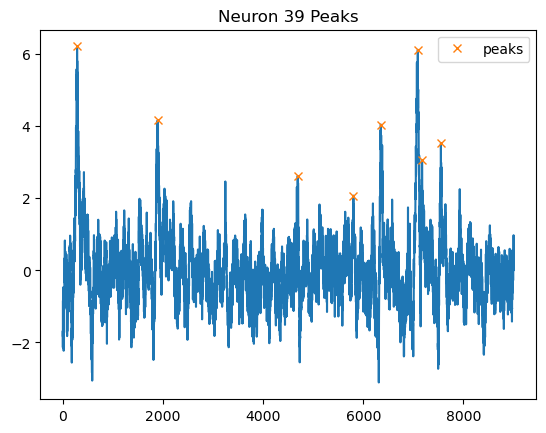

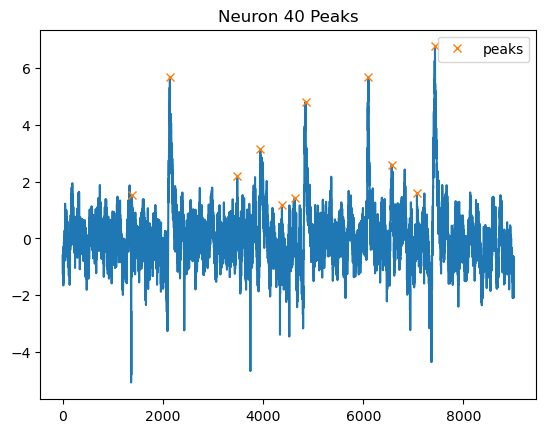

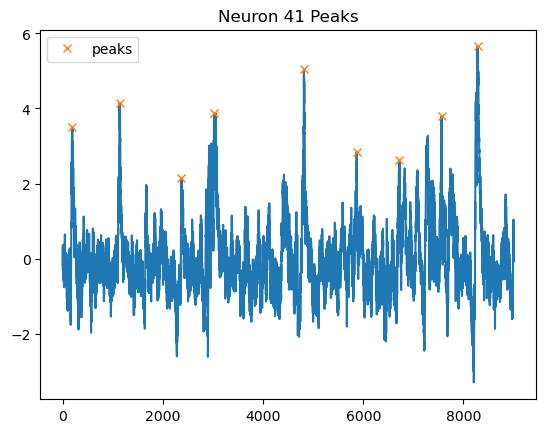

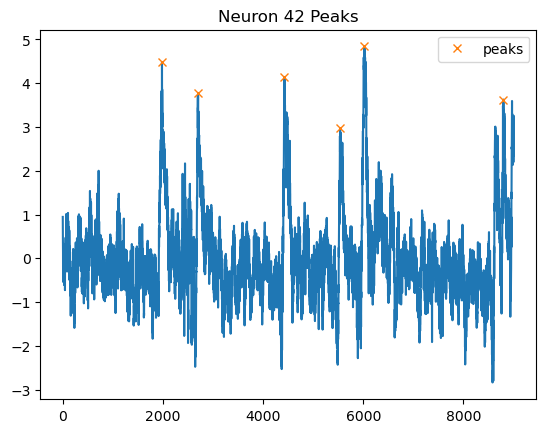

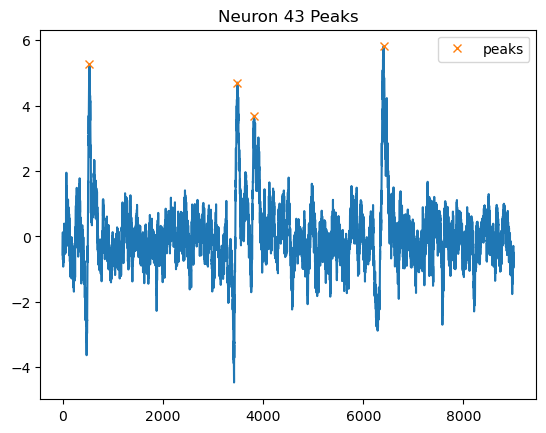

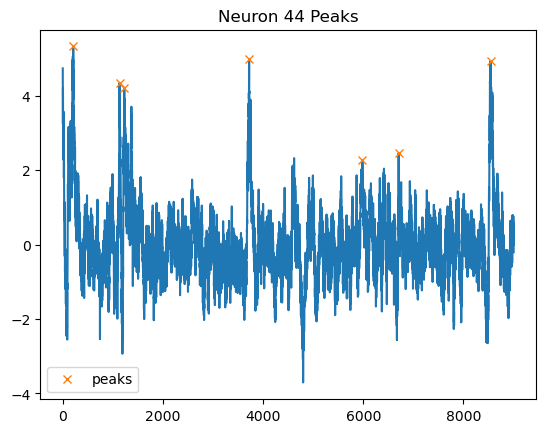

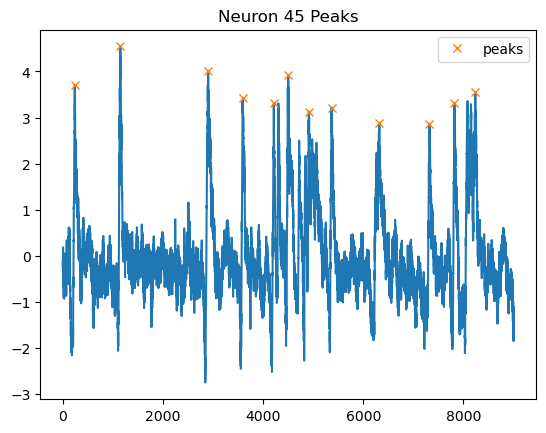

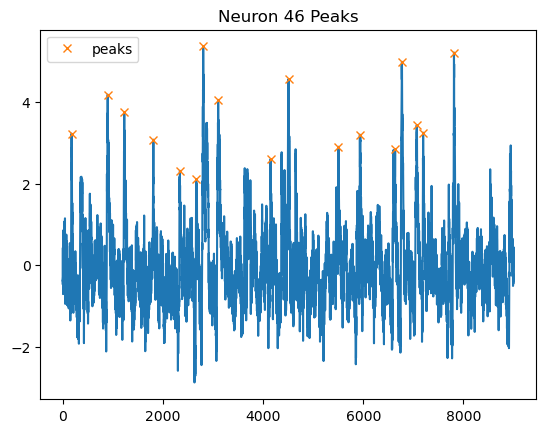

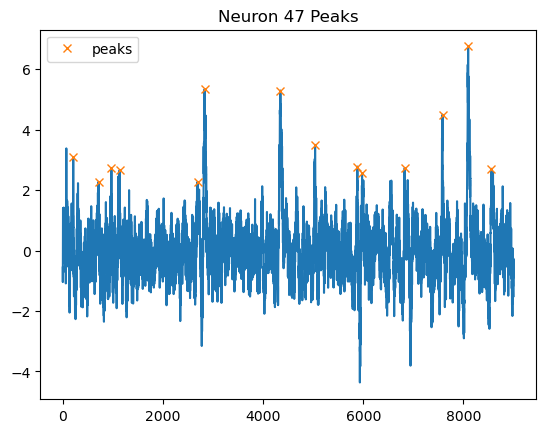

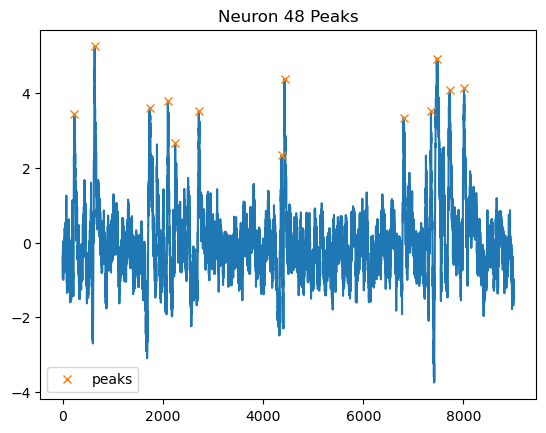

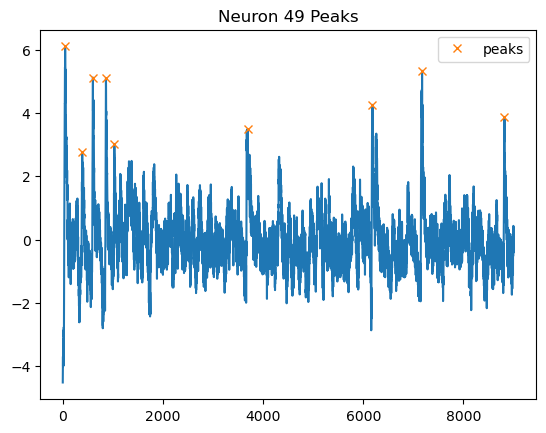

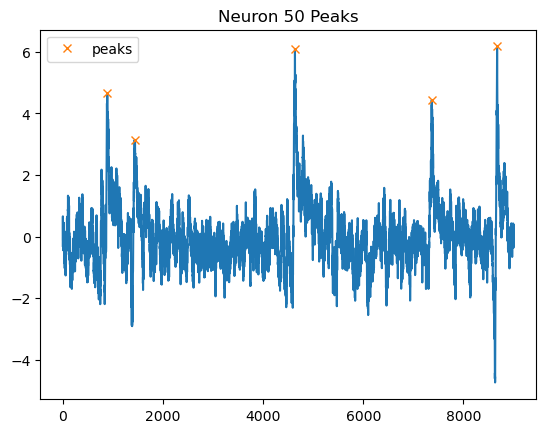

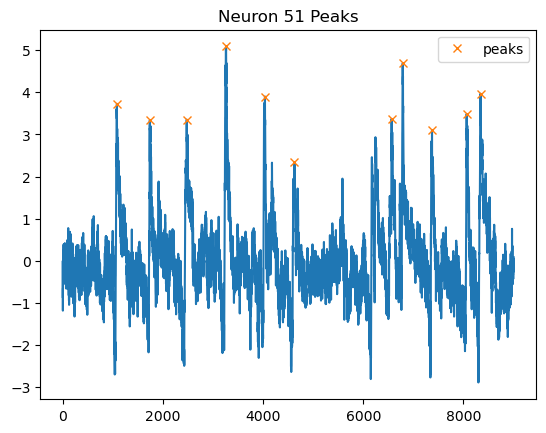

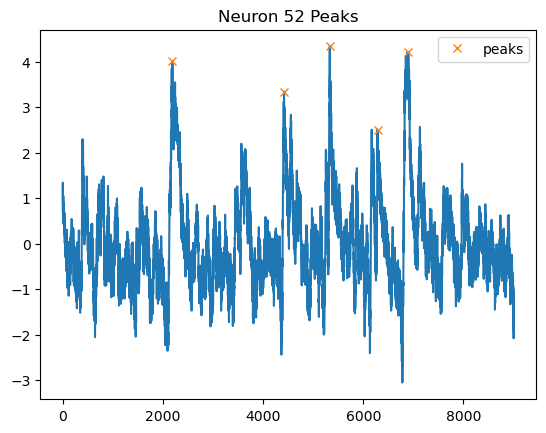

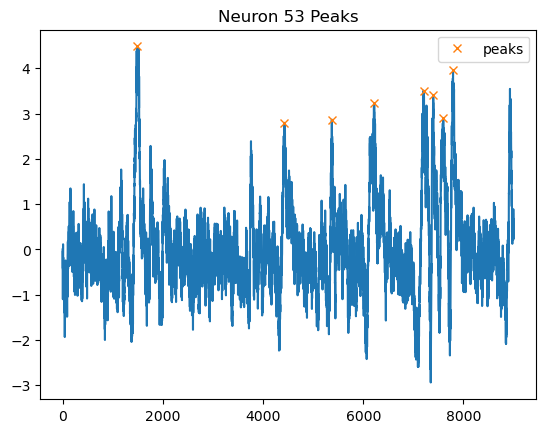

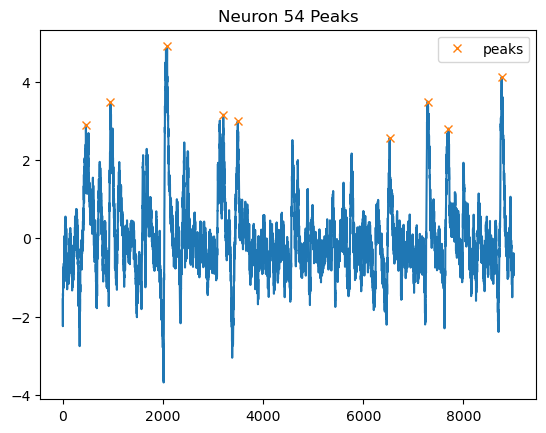

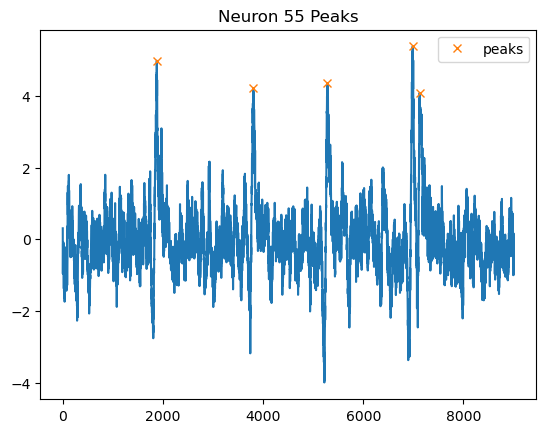

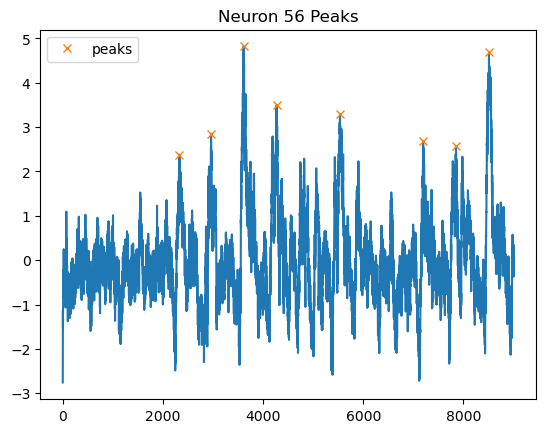

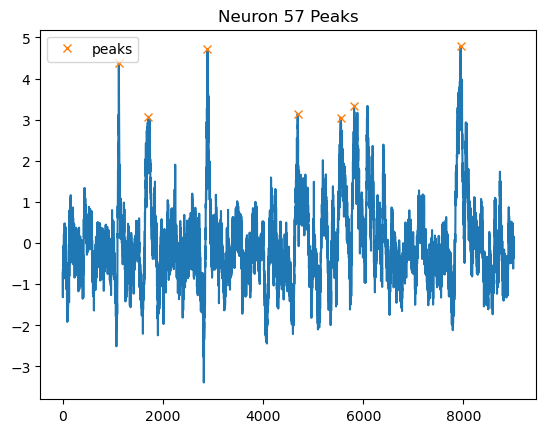

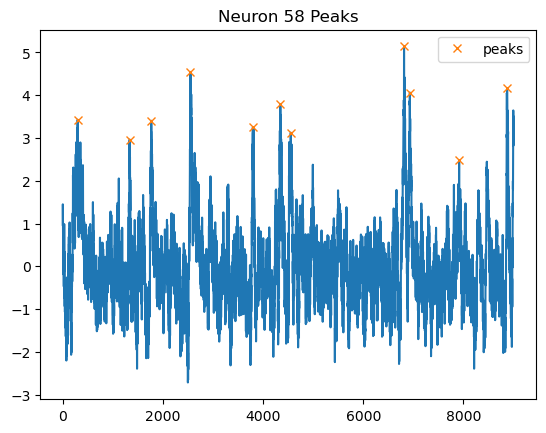

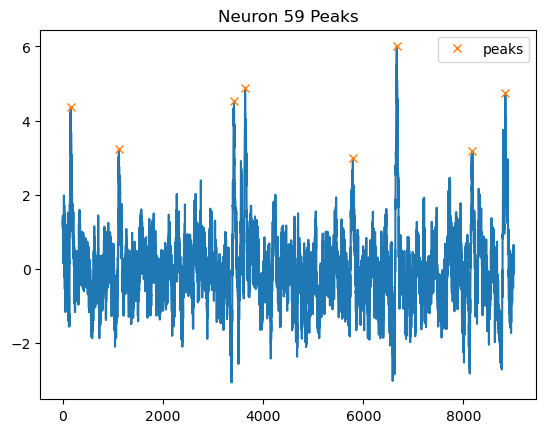

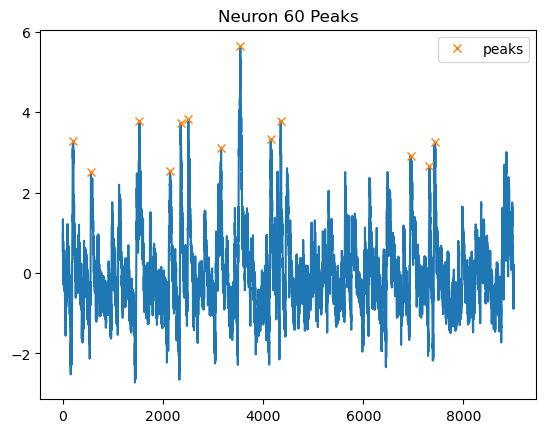

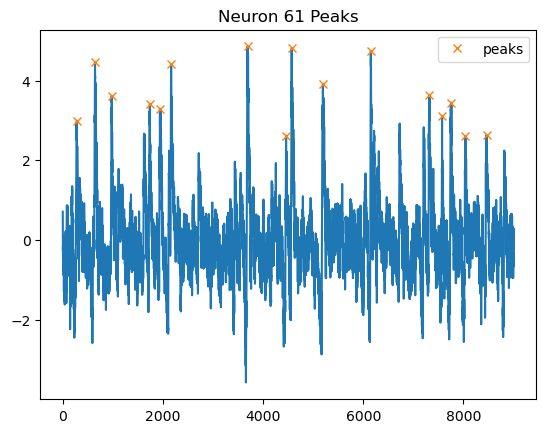

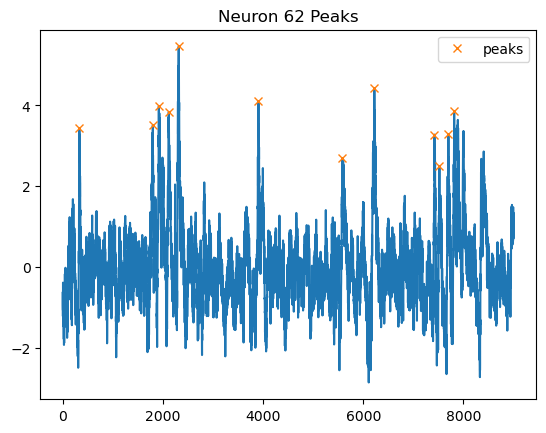

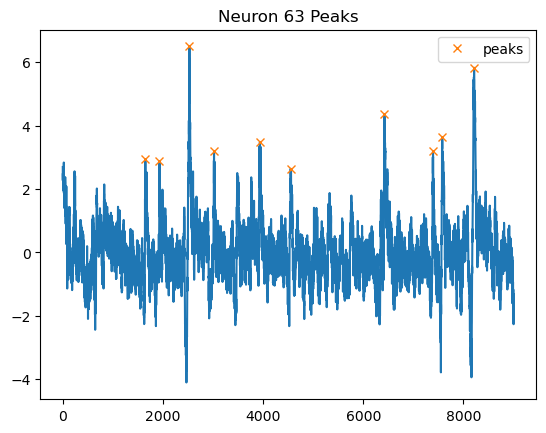

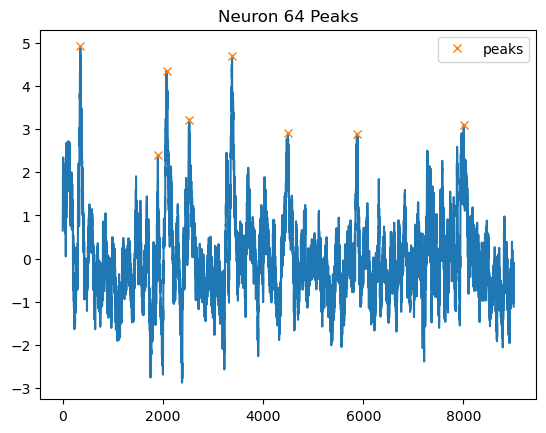

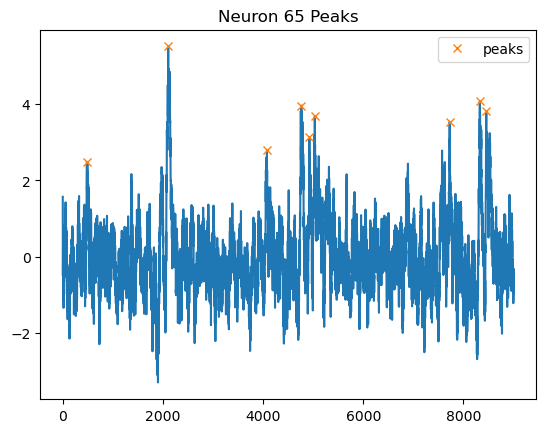

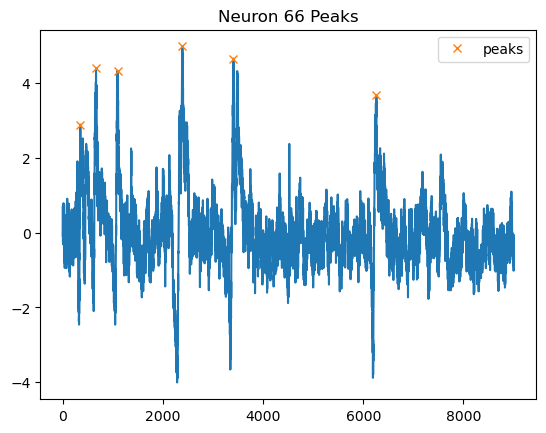

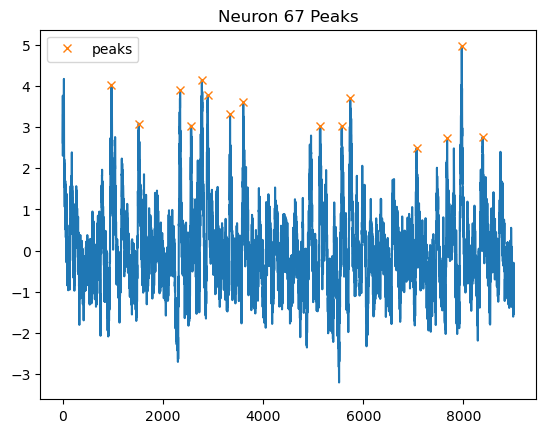

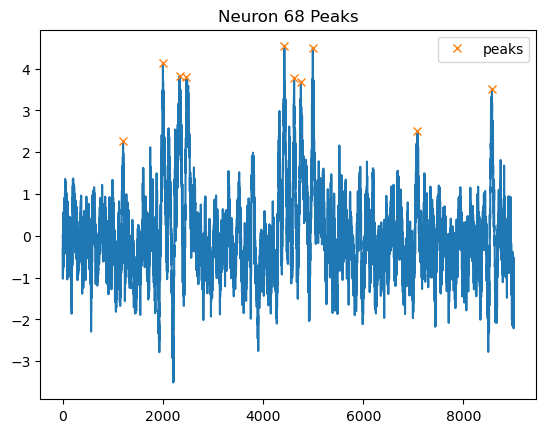

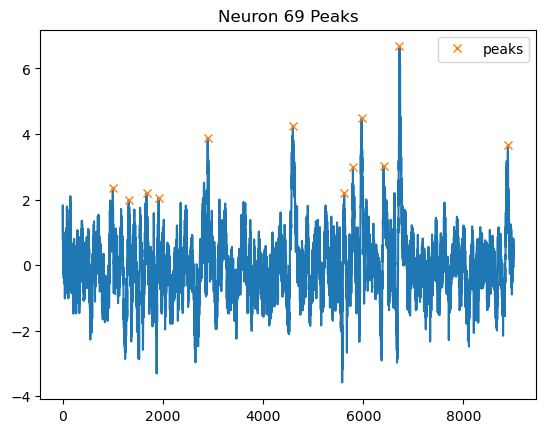

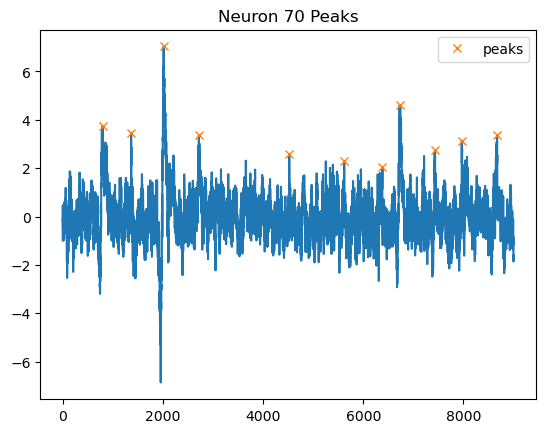

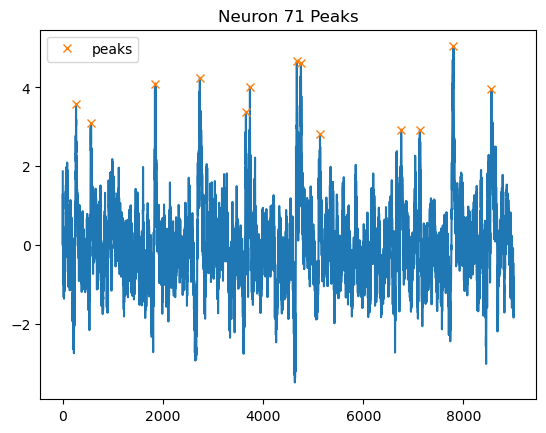

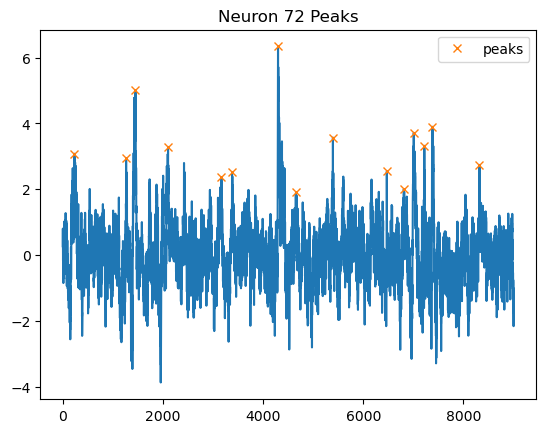

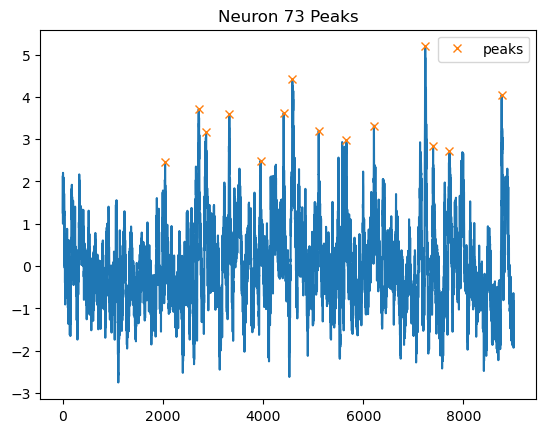

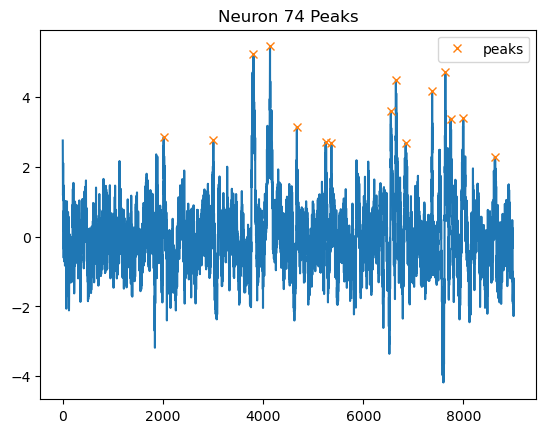

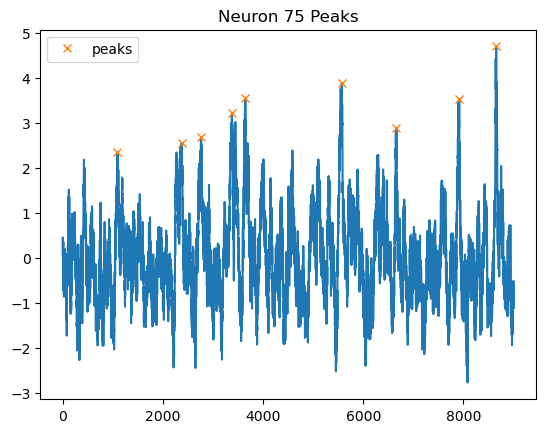

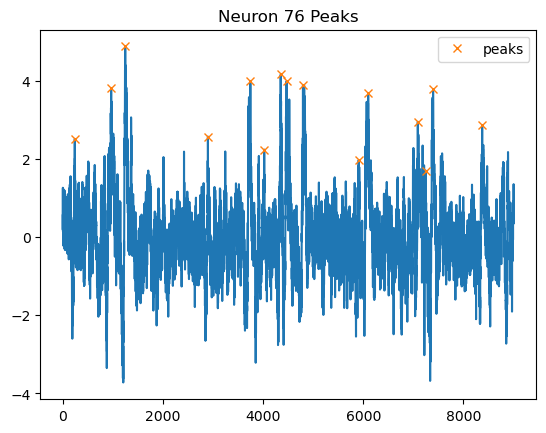

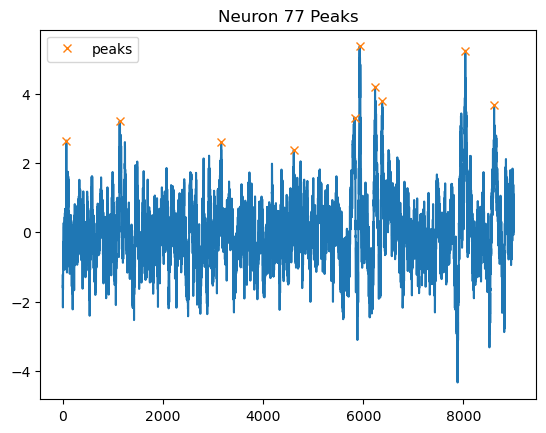

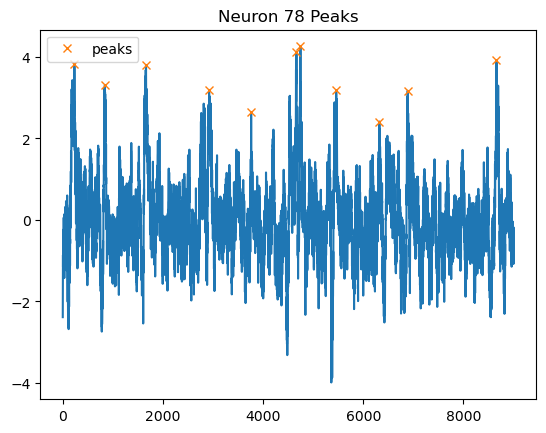

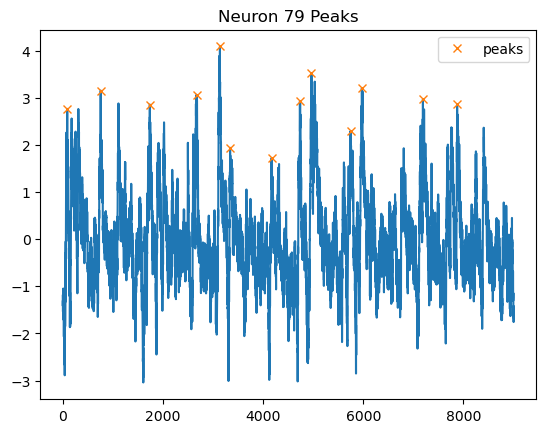

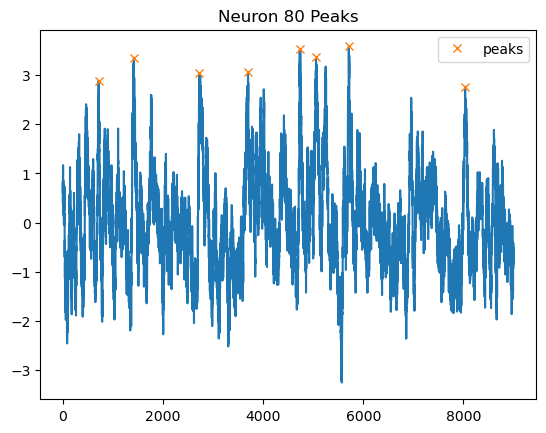

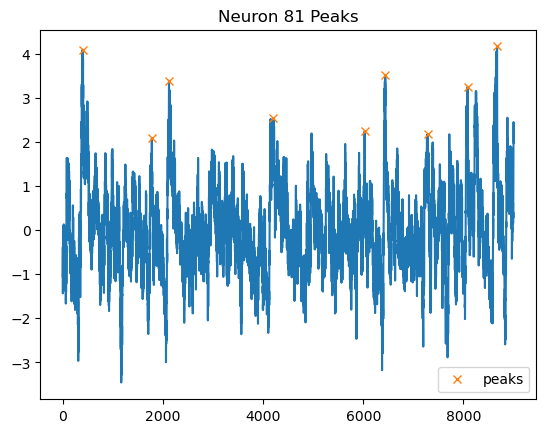

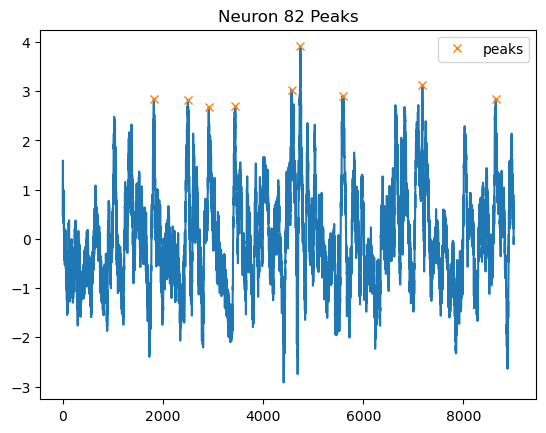

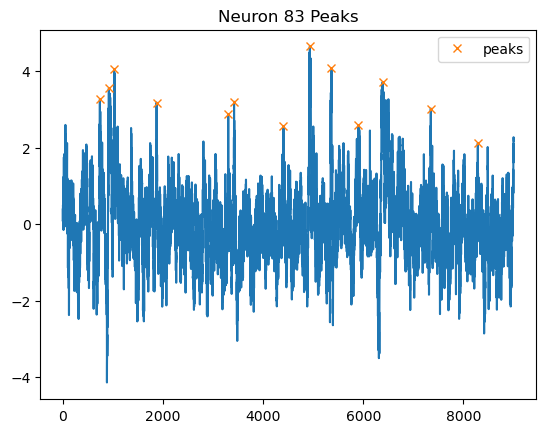

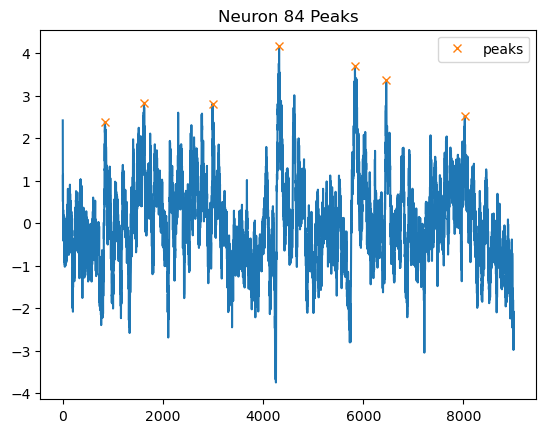

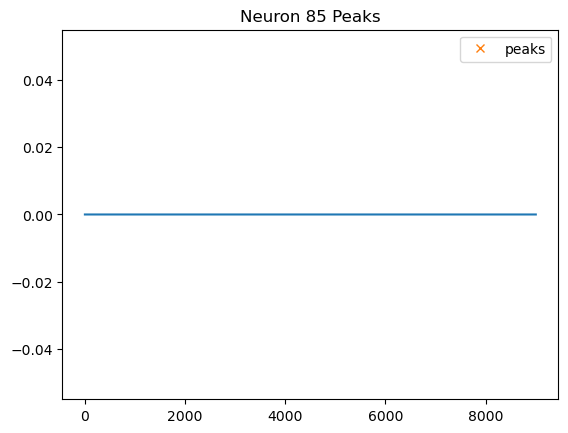

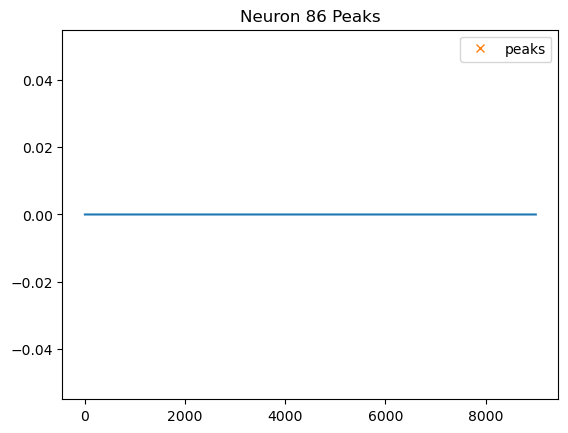

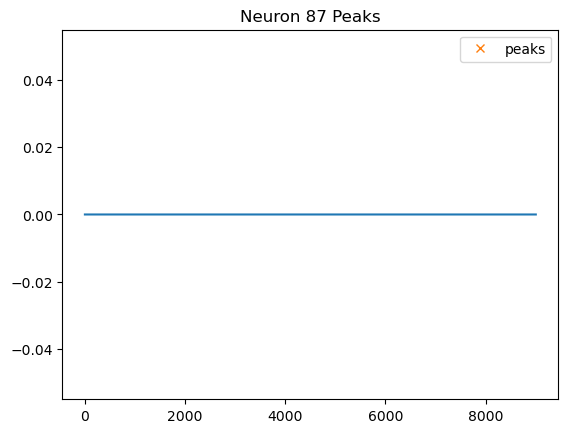

In [93]:
# 修改路径
trace_path = "F:/AAA-RXC/PL8-4sessions/session_1_trace.csv"
event_path = "F:/AAA-RXC/PL8-4sessions/event1.xlsx"

# 定义fps
fps = 15
trace_df = pd.read_csv(trace_path, index_col=0)

session = add_event_label(trace_df, event_path)
# 全部event
whole_df = session.drop('Frame_Label', axis=1)
# 某个event（Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_left）
In_all_df = check_frame_interval(session, 'In_all')
# 看全部event的图像，在这里改成whole_df；看某一个event的图像，在这里改成对应的名称：Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_left

In_all_eventrate, In_all_amplitude, In_all_amplitude_00, df_array, peak_info_list = event_rate(In_all_df, fps)
# 绘图
plot_peak_info(df_array, peak_info_list)


# TransientRate_Amplitude for each mouse

In [116]:
root_path = 'F:/AAA-RXC'
data_path = os.path.join(root_path)
IL1_list = ['PL7-4sessions',]
session_ids = [1,2,3,4]

In [ ]:
print('IL')
IL1_df_e_list = []  # event rate数据列表
IL1_df_a_list = []  # Amplitude数据列表
IL1_df_a_00_list = []  # Amplitude_With0数据列表


for i in range(len(IL1_list)):
    
    mouse_name = IL1_list[i]
    mouseSummary = IL1_list[i]
    
    print('Processing', mouse_name)
    
    #mice = os.path.join(root_path, mouse_name)
    #trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    #event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx_process.xlsx")
    #event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx_process.xlsx")
    #event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx_process.xlsx")

    # 选择FPS
    if mouse_name.split('_')[0] in ['PL1-4sessions',]:
        fps = 15
    else:
        fps = 15
        
    #dfLabeled, session_1, session_2, session_3 = add_event_label(trace, event1, event2, event3)
    #session_list = [session_1, session_2, session_3]
    sessionName_list = ['session_1', 'session_2', 'session_3', 'session_4']
    
    
    #for session_index in range(len(sessionName_list)):
    for sessionID in session_ids:
            
            
            event = os.path.join(data_path, mouseSummary, f"event{sessionID}.xlsx")
            session = pd.read_csv(os.path.join(data_path, mouseSummary, f"session_{sessionID}_trace.csv"))
            #session = session_list[session_index]
            sessionName = sessionName_list[sessionID-1]

            whole_df = session.drop('Frame_Label', axis=1)  
            sniff_df = check_frame_interval(session, 'sniff')  
            sniffed_df = check_frame_interval(session, 'sniffed')  
            freezing_df = check_frame_interval(session, 'freezing')   
            cs_df = check_frame_interval(session, 'cs') 
    

            # 计算各种事件率和峰值均值
            whole_eventrate, whole_amplitude, whole_amplitude_00, _, _= event_rate(whole_df, fps)
            sniff_eventrate, sniff_amplitude, sniff_amplitude_00, _, _ = event_rate(sniff_df, fps)
            sniffed_eventrate, sniffed_amplitude, sniffed_amplitude_00, _, _ = event_rate(sniffed_df, fps)
            freezing_eventrate, freezing_amplitude, freezing_amplitude_00, _, _ = event_rate(freezing_df, fps)
            cs_eventrate, cs_amplitude, cs_amplitude_00, _, _ = event_rate(cs_df, fps)
    
            
            # event rate
            IL1_dic_e = {'mouse_name': mouse_name,
                        'session': sessionName,
                        'whole_seesion': whole_eventrate, 
                        'sniff': sniff_eventrate, 
                        'sniffed': sniffed_eventrate,
                        'freezing/exploration': freezing_eventrate,
                        'cs/SI': cs_eventrate}
            IL1_df_e = pd.DataFrame.from_dict(IL1_dic_e, orient='index').T
            IL1_df_e_list.append(IL1_df_e)

            # Amplitude
            IL1_dic_a = {'mouse_name': mouse_name,
                        'session': sessionName,
                        'whole_seesion': whole_amplitude, 
                        'sniff': sniff_amplitude, 
                        'sniffed': sniffed_amplitude,
                        'freezing/exploration': freezing_amplitude, 
                        'cs/SI': cs_amplitude}
            IL1_df_a = pd.DataFrame.from_dict(IL1_dic_a, orient='index').T
            IL1_df_a_list.append(IL1_df_a)

            # Amplitude_With0
            IL1_dic_a_00 = {'mouse_name': mouse_name,
                        'session': sessionName,
                        'whole_seesion': whole_amplitude_00, 
                        'sniff': sniff_amplitude_00, 
                        'sniffed': sniffed_amplitude_00,
                        'freezing/exploration': freezing_amplitude_00, 
                        'cs/SI': cs_amplitude_00}
            IL1_df_a_00 = pd.DataFrame.from_dict(IL1_dic_a_00, orient='index').T
            IL1_df_a_00_list.append(IL1_df_a_00)

# 合并数据列表为数据框
IL1_df_ee = pd.concat(IL1_df_e_list)
IL1_df_aa = pd.concat(IL1_df_a_list)
IL1_df_aa_00 = pd.concat(IL1_df_a_00_list)


# 将数据框保存为CSV文件
IL1_df_ee.to_csv('F:/AAA-RXC/Results/Eventrate.csv')
IL1_df_aa.to_csv('F:/AAA-RXC/Results/Amplitude.csv')
IL1_df_aa_00.to_csv('F:/AAA-RXC/Results/Amplitude_With0.csv')




IL
Processing PL7-4sessions


c:\Users\DELL\anaconda3\envs\mouse\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\DELL\anaconda3\envs\mouse\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\DELL\anaconda3\envs\mouse\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\DELL\anaconda3\envs\mouse\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
